In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import networkx as nx
import folium


url = "https://data.humdata.org/api/3/action/package_show"
response = requests.get(url, params={'id': 'idmc-event-data-for-ukr'})
resources = response.json()['result']['resources']
for r in resources:
    print(r['name'], r['format'], r['url'])



In [ ]:
csv_url = "https://data.humdata.org/dataset/52880c3a-715d-4e01-b75a-1fc3f64babf6/resource/1743ee20-1def-4326-8387-beed71c9a0eb/download/event_data_ukr.csv"
df_ukr = pd.read_csv(csv_url)
print(df_ukr.shape)
df_ukr.head()

In [ ]:
print(df_ukr.shape)
df_ukr.dtypes

In [ ]:
print(df_ukr['displacement_type'].value_counts())
print()
print(df_ukr['figure'].describe())
print()
print(df_ukr['year'].value_counts().sort_index())


In [ ]:
df_ukr['description'].iloc[0]


In [ ]:
df_ukr['displacement_date'] = pd.to_datetime(df_ukr['displacement_date'])
print(df_ukr['displacement_date'].min(), '→', df_ukr['displacement_date'].max())

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(df_ukr['longitude'], df_ukr['latitude'], 
            s=df_ukr['figure'] / 5, 
            alpha=0.5, c='red')
plt.title('Ukraine Displacement Events (size = people displaced)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [10]:
m = folium.Map(location=[48.5, 35], zoom_start=6)

for _, row in df_ukr.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(row['figure'] / 200, 1.5),
        color='red',
        fill=True,
        fill_opacity=0.5,
        popup=row['description']
    ).add_to(m)

m.save('ukraine_displacement.html')
m

In [11]:
df_ukr['displacement_occurred'].value_counts()

displacement_occurred
Displacement without preventive evacuations reported    120
Name: count, dtype: int64

In [13]:
df_ukr['description'].str.contains('destroyed').sum()

np.int64(78)

In [14]:
df_ukr['event_type'] = df_ukr['description'].str.contains('destroyed').map({True: 'destroyed', False: 'evacuated'})
df_ukr['event_type'].value_counts()

event_type
evacuated    119
destroyed     78
Name: count, dtype: int64

In [15]:
m = folium.Map(location=[48.5, 35], zoom_start=6)

colors = {'destroyed': 'red', 'evacuated': 'blue'}

for _, row in df_ukr.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=max(row['figure'] / 200, 1.5),
        color=colors[row['event_type']],
        fill=True,
        fill_opacity=0.5,
        popup=row['description']
    ).add_to(m)

m.save('ukraine_displacement_typed.html')
m

In [16]:
df_ukr['displacement_date'] = pd.to_datetime(df_ukr['displacement_date'])

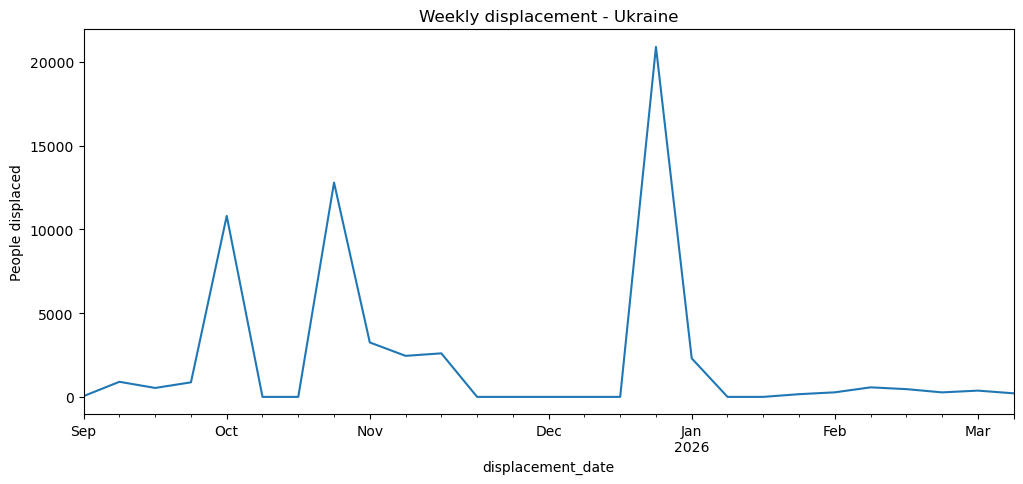

In [17]:
weekly = df_ukr.set_index('displacement_date').resample('W')['figure'].sum()
weekly.plot(figsize=(12,5), title='Weekly displacement - Ukraine')
plt.ylabel('People displaced')
plt.show()

In [18]:
jan_spike = df_ukr[(df_ukr['displacement_date'] >= '2025-12-15') & 
                    (df_ukr['displacement_date'] <= '2026-01-15')]
jan_spike = jan_spike.sort_values('figure', ascending=False)
jan_spike[['displacement_date', 'figure', 'locations_name', 'description']].head()

,displacement_date,figure,locations_name,description
108,2025-12-24,9600,"Dnipropetrovsk Oblast, Ukraine","Ukraine: 9,600 displacements (evacuated), 15 N..."
109,2025-12-24,6300,"Donetsk Oblast, Ukraine","Ukraine: 6,300 displacements (evacuated), 15 N..."
112,2025-12-24,2800,"Kharkiv Oblast, Ukraine","Ukraine: 2,800 displacements (evacuated), 15 N..."
113,2025-12-24,1700,"Zaporizhia Oblast, Ukraine","Ukraine: 1,700 displacements (evacuated), 15 N..."
107,2026-01-02,1400,"Donetsk Oblast, Ukraine","Ukraine: 1,400 displacements (evacuated), 25 D..."


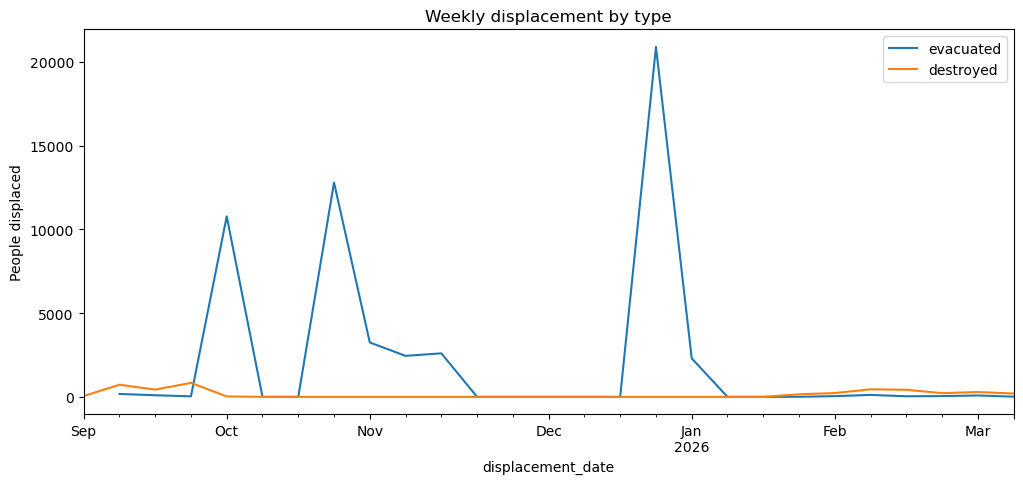

In [19]:
for etype in ['evacuated', 'destroyed']:
    subset = df_ukr[df_ukr['event_type'] == etype].set_index('displacement_date')
    subset.resample('W')['figure'].sum().plot(label=etype, figsize=(12,5))
plt.legend()
plt.title('Weekly displacement by type')
plt.ylabel('People displaced')
plt.show()